Dolan Malang - Pipeline Data untuk LK-01Notebook ini menarik data dari Open-Meteo untuk lokasi-lokasi hangout di Malang Raya,menghitung Outdoor Comfort Index sebagai label, dan menyimpan snapshot harian.Semua endpoint gratis dan tanpa API key untuk penggunaan non-komersial.
Alur: ambil prakiraan -> ambil kualitas udara -> gabung -> hitung index -> simpan snapshot -> bukti bias

In [ ]:
import json
import requests

import pandas as pd
import numpy as np
from datetime import datetime, timezone, timedelta
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)
WIB = timezone(timedelta(hours=7))

print("siap:", datetime.now(WIB).strftime("%Y-%m-%d %H:%M WIB"))

siap: 2026-08-28 23:21 WIB


1. Daftar lokasiGanti atau tambah sesuai selera. Kolom `activity_tags` nanti dipakai lapisan rekomendasi.Koordinat bisa kamu ambil dari Google Maps (klik kanan, salin koordinat).

In [ ]:
LOCATIONS = [
    {"name": "Kayutangan Heritage", "lat": -7.9797, "lon": 112.6304, "tags": ["jalan", "ngafe", "foto"]},
    {"name": "Alun-Alun Malang",    "lat": -7.9826, "lon": 112.6308, "tags": ["jalan", "santai"]},
    {"name": "Kampung Warna Jodipan","lat": -7.9880, "lon": 112.6390, "tags": ["foto", "jalan"]},
    {"name": "Gunung Panderman",    "lat": -7.9019, "lon": 112.5089, "tags": ["muncak", "camping"]},
    {"name": "Coban Talun",         "lat": -7.8100, "lon": 112.5300, "tags": ["alam", "camping"]},
    {"name": "Kota Batu",           "lat": -7.8672, "lon": 112.5239, "tags": ["jalan", "ngafe"]},
    {"name": "Bromo",               "lat": -7.9425, "lon": 112.9530, "tags": ["sunrise", "alam"]},
    {"name": "Pantai Balekambang",  "lat": -8.4028, "lon": 112.5333, "tags": ["pantai", "sunset"]},
]

loc_df = pd.DataFrame(LOCATIONS)
print(len(loc_df), "lokasi")
loc_df

8 lokasi


,name,lat,lon,tags
0,Kayutangan Heritage,-7.9797,112.6304,"[jalan, ngafe, foto]"
1,Alun-Alun Malang,-7.9826,112.6308,"[jalan, santai]"
2,Kampung Warna Jodipan,-7.9880,112.6390,"[foto, jalan]"
3,Gunung Panderman,-7.9019,112.5089,"[muncak, camping]"
4,Coban Talun,-7.8100,112.5300,"[alam, camping]"
5,Kota Batu,-7.8672,112.5239,"[jalan, ngafe]"
6,Bromo,-7.9425,112.9530,"[sunrise, alam]"
7,Pantai Balekambang,-8.4028,112.5333,"[pantai, sunset]"


2. Tarik prakiraan untuk semua lokasi sekaligusOpen-Meteo menerima daftar koordinat dipisah koma dalam satu request, dan mengembalikanlist JSON dengan urutan yang sama seperti input. Jauh lebih hemat daripada looping per lokasi.`forecast_days=7` memberi horizon seminggu, `past_days=7` menarik seminggu ke belakangsekaligus sehingga kamu punya bahan awal tanpa menunggu.

In [ ]:
FORECAST_URL = "https://api.open-meteo.com/v1/forecast"
HOURLY_VARS = [
    "temperature_2m", "apparent_temperature", "relative_humidity_2m",
    "precipitation", "precipitation_probability", "cloud_cover",
    "wind_speed_10m", "wind_gusts_10m", "uv_index", "visibility",
    "is_day", "weather_code",
]
import time
def get_json(url, params, tries=4):
    # Open-Meteo membalas 429 kalau bobot request terlalu besar,
    # yaitu jumlah lokasi dikali jumlah variabel dikali jumlah hari.
    for i in range(tries):
        r = requests.get(url, params=params, timeout=90)
        if r.status_code == 429:
            wait = 20 * (i + 1)
            print(f"  kena rate limit, tunggu {wait} detik...")
            time.sleep(wait)
            continue
        r.raise_for_status()
        payload = r.json()
        return [payload] if isinstance(payload, dict) else payload
    raise RuntimeError("masih 429 setelah beberapa percobaan, kurangi lokasi atau variabel")
def fetch_forecast(locations, past_days=7, forecast_days=7, chunk=3):
    # Ambil per kelompok lokasi supaya bobot tiap request tetap kecil.
    out = []
    for i in range(0, len(locations), chunk):
        grup = locations[i:i + chunk]
        print(f"  ambil {[l['name'] for l in grup]}")
        params = {
            "latitude":  ",".join(str(l["lat"]) for l in grup),
            "longitude": ",".join(str(l["lon"]) for l in grup),
            "hourly": ",".join(HOURLY_VARS),
            "timezone": "Asia/Jakarta",
            "past_days": past_days,
            "forecast_days": forecast_days,
        }
        out.extend(get_json(FORECAST_URL, params))
        time.sleep(1)
    return out
raw = fetch_forecast(LOCATIONS)
print("jumlah blok:", len(raw))
print("variabel:", list(raw[0]["hourly"].keys()))
print("rentang waktu:", raw[0]["hourly"]["time"][0], "s.d.", raw[0]["hourly"]["time"][-1])

  ambil ['Kayutangan Heritage', 'Alun-Alun Malang', 'Kampung Warna Jodipan']
  ambil ['Gunung Panderman', 'Coban Talun', 'Kota Batu']
  ambil ['Bromo', 'Pantai Balekambang']
jumlah blok: 8
variabel: ['time', 'temperature_2m', 'apparent_temperature', 'relative_humidity_2m', 'precipitation', 'precipitation_probability', 'cloud_cover', 'wind_speed_10m', 'wind_gusts_10m', 'uv_index', 'visibility', 'is_day', 'weather_code']
rentang waktu: 2026-08-22T00:00 s.d. 2026-09-04T23:00


3. Ubah JSON menjadi tabel panjang (long format)Satu baris = satu lokasi pada satu jam. Format ini yang nanti masuk ke feature storedan paling nyaman untuk time-series.Perhatikan `elevation` ikut disimpan. Ini fitur penting karena bias prakiraan sangatbergantung pada ketinggian, dan grid model global tidak menangkap lereng gunung.

In [ ]:
def to_dataframe(payload, locations):
    frames = []
    for meta, loc in zip(payload, locations):
        h = meta["hourly"]
        df = pd.DataFrame(h)
        df["time"] = pd.to_datetime(df["time"])
        df.insert(0, "location", loc["name"])
        df["lat"] = loc["lat"]
        df["lon"] = loc["lon"]
        df["elevation"] = meta.get("elevation")
        frames.append(df)
    out = pd.concat(frames, ignore_index=True)
    out["hour"] = out["time"].dt.hour
    out["dayofweek"] = out["time"].dt.dayofweek
    out["is_weekend"] = out["dayofweek"].isin([5, 6]).astype(int)
    return out

wx = to_dataframe(raw, LOCATIONS)
print(wx.shape)
wx.head()

(2688, 20)


,location,time,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation,precipitation_probability,cloud_cover,wind_speed_10m,wind_gusts_10m,uv_index,visibility,is_day,weather_code,lat,lon,elevation,hour,dayofweek,is_weekend
0,Kayutangan Heritage,2026-08-22 00:00:00,21.2,25.5,99,0.0,22,99,1.3,7.9,0.0,4100.0,0,3,-7.9797,112.6304,446.0,0,5,1
1,Kayutangan Heritage,2026-08-22 01:00:00,21.0,25.2,99,0.0,24,100,1.1,6.8,0.0,880.0,0,3,-7.9797,112.6304,446.0,1,5,1
2,Kayutangan Heritage,2026-08-22 02:00:00,21.0,25.2,100,0.0,23,100,1.2,7.2,0.0,1620.0,0,3,-7.9797,112.6304,446.0,2,5,1
3,Kayutangan Heritage,2026-08-22 03:00:00,20.9,25.0,100,0.0,21,100,1.0,7.2,0.0,460.0,0,3,-7.9797,112.6304,446.0,3,5,1
4,Kayutangan Heritage,2026-08-22 04:00:00,20.7,24.7,100,0.0,22,99,1.4,8.3,0.0,160.0,0,3,-7.9797,112.6304,446.0,4,5,1


In [ ]:
# cek perbedaan elevasi antar lokasi, ini yang bikin bias per lokasi berbedawx.groupby("location").agg(    elevation=("elevation", "first"),    suhu_rata=("temperature_2m", "mean"),    suhu_min=("temperature_2m", "min"),    suhu_max=("temperature_2m", "max"),).sort_values("elevation")

4. Tambahkan kualitas udaraEndpoint terpisah, host berbeda, tapi parameternya konsisten. Data dari CAMS.

In [ ]:
AQ_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"
def fetch_air_quality(locations, past_days=7, forecast_days=5, chunk=4):
    frames = []
    for i in range(0, len(locations), chunk):
        grup = locations[i:i + chunk]
        params = {
            "latitude":  ",".join(str(l["lat"]) for l in grup),
            "longitude": ",".join(str(l["lon"]) for l in grup),
            "hourly": "pm2_5,pm10,us_aqi",
            "timezone": "Asia/Jakarta",
            "past_days": past_days,
            "forecast_days": forecast_days,
        }
        for meta, loc in zip(get_json(AQ_URL, params), grup):
            d = pd.DataFrame(meta["hourly"])
            d["time"] = pd.to_datetime(d["time"])
            d.insert(0, "location", loc["name"])
            frames.append(d)
        time.sleep(1)
    return pd.concat(frames, ignore_index=True)
aq = fetch_air_quality(LOCATIONS)
df = wx.merge(aq, on=["location", "time"], how="left")
print(df.shape)
df[["location", "time", "temperature_2m", "precipitation", "us_aqi"]].head()

(2688, 23)


,location,time,temperature_2m,precipitation,us_aqi
0,Kayutangan Heritage,2026-08-22 00:00:00,21.2,0.0,122.0
1,Kayutangan Heritage,2026-08-22 01:00:00,21.0,0.0,121.0
2,Kayutangan Heritage,2026-08-22 02:00:00,21.0,0.0,120.0
3,Kayutangan Heritage,2026-08-22 03:00:00,20.9,0.0,119.0
4,Kayutangan Heritage,2026-08-22 04:00:00,20.7,0.0,118.0


5. Outdoor Comfort Index, ini label kamuBagian terpenting dari seluruh proyek. Baca pelan-pelan.Index dihitung sebagai 100 dikurangi sejumlah penalti. Setiap penalti punya alasan fisikyang bisa kamu pertanggungjawabkan di dokumen, bukan angka asal.Yang menjadikan ini label yang sah, bukan sekadar aturan:- Saat dihitung dari data observasi (kondisi yang sudah terjadi), hasilnya adalah ground truth- Saat dihitung dari data prakiraan, hasilnya adalah baseline naif- Model kamu bertugas memprediksi nilai ground truth itu beberapa hari sebelumnya, dan  keberhasilannya diukur dari seberapa jauh ia mengalahkan baseline naifBobot per aktivitas berbeda karena angin kencang fatal untuk mendaki tapi tidak masalahuntuk duduk di kafe.

In [ ]:
def _pen_heat(app_temp, ideal_lo=22, ideal_hi=29):
    below = np.clip(ideal_lo - app_temp, 0, None) * 2.5
    above = np.clip(app_temp - ideal_hi, 0, None) * 3.5
    return below + above

def _pen_rain(precip):
    return np.clip(precip, 0, None) * 22

def _pen_uv(uv):
    return np.clip(uv - 7, 0, None) * 4

def _pen_wind(wind):
    return np.clip(wind - 20, 0, None) * 1.6

def _pen_vis(vis_m):
    vis_km = vis_m / 1000.0
    return np.clip(6 - vis_km, 0, None) * 5

def _pen_aqi(aqi):
    return np.clip(aqi - 80, 0, None) * 0.35

WEIGHTS = {
    "jalan":   dict(heat=1.0, rain=1.0, uv=1.0, wind=0.5, vis=0.2, aqi=1.0),
    "ngafe":   dict(heat=0.5, rain=0.6, uv=0.3, wind=0.2, vis=0.1, aqi=0.6),
    "muncak":  dict(heat=0.7, rain=1.4, uv=0.8, wind=1.5, vis=1.5, aqi=0.8),
    "foto":    dict(heat=0.7, rain=1.2, uv=0.5, wind=0.4, vis=1.2, aqi=0.7),
    "camping": dict(heat=0.9, rain=1.5, uv=0.4, wind=1.3, vis=0.6, aqi=0.7),
    "sunset":  dict(heat=0.6, rain=1.0, uv=0.2, wind=0.5, vis=1.4, aqi=0.9),
}

def comfort_index(frame, activity="jalan"):
    w = WEIGHTS[activity]
    pen = (
        w["heat"] * _pen_heat(frame["apparent_temperature"])
        + w["rain"] * _pen_rain(frame["precipitation"])
        + w["uv"]   * _pen_uv(frame["uv_index"])
        + w["wind"] * _pen_wind(frame["wind_speed_10m"])
        + w["vis"]  * _pen_vis(frame["visibility"])
        + w["aqi"]  * _pen_aqi(frame["us_aqi"].fillna(50))
    )
    return np.clip(100 - pen, 0, 100).round(1)

for act in WEIGHTS:
    df[f"score_{act}"] = comfort_index(df, act)
df[["location", "time", "apparent_temperature", "precipitation",
    "score_jalan", "score_muncak", "score_ngafe"]].head(10)

,location,time,apparent_temperature,precipitation,score_jalan,score_muncak,score_ngafe
0,Kayutangan Heritage,2026-08-22 00:00:00,25.5,0.0,83.4,74.0,90.2
1,Kayutangan Heritage,2026-08-22 01:00:00,25.2,0.0,80.5,50.1,88.8
2,Kayutangan Heritage,2026-08-22 02:00:00,25.2,0.0,81.6,56.0,89.4
3,Kayutangan Heritage,2026-08-22 03:00:00,25.0,0.0,80.8,47.5,89.0
4,Kayutangan Heritage,2026-08-22 04:00:00,24.7,0.0,80.9,45.6,89.1
5,Kayutangan Heritage,2026-08-22 05:00:00,24.4,0.0,81.2,45.5,89.3
6,Kayutangan Heritage,2026-08-22 06:00:00,24.7,0.0,82.2,51.1,89.8
7,Kayutangan Heritage,2026-08-22 07:00:00,25.1,0.0,88.4,90.8,93.1
8,Kayutangan Heritage,2026-08-22 08:00:00,26.0,0.0,84.6,57.0,91.2
9,Kayutangan Heritage,2026-08-22 09:00:00,27.2,0.0,85.8,63.6,91.8


In [ ]:
# Rekomendasi hari ini: ranking lokasi pada jam-jam sore untuk aktivitas jalannow = pd.Timestamp.now(tz=None).floor("h")sore = df[(df["time"] >= now) & (df["time"] <= now + pd.Timedelta(hours=12)) & (df["hour"].between(15, 18))]ranking = (sore.groupby("location")             .agg(skor=("score_jalan", "mean"),                  suhu=("apparent_temperature", "mean"),                  hujan_mm=("precipitation", "sum"),                  aqi=("us_aqi", "mean"))             .sort_values("skor", ascending=False)             .round(1))ranking

6. Simpan snapshot, inilah "data yang bertambah"Setiap kali dijalankan, satu file baru bertimestamp. Setelah beberapa hari kamu punyariwayat prakiraan yang bisa dibandingkan dengan kenyataan.Untuk LK-02 dan seterusnya, sel ini dipindah ke skrip yang dijalankan GitHub Actionsdengan jadwal cron, dan hasilnya di-commit atau didorong ke storage.

In [ ]:
import os
os.makedirs("data/raw", exist_ok=True)
stamp = datetime.now(WIB).strftime("%Y%m%dT%H%M")
path = f"data/raw/gasgak_{stamp}.csv"
df.to_csv(path, index=False)
print("tersimpan:", path, "|", len(df), "baris")
print(sorted(os.listdir("data/raw"))[-5:])

tersimpan: data/raw/gasgak_20260829T0021.csv | 2688 baris
['gasgak_20260829T0021.csv']


7. Data historis untuk melatih model pertamaERA5 reanalysis tersedia sejak 1940 dan gratis. Ambil beberapa tahun untuk satu atau dualokasi agar model punya bahan belajar pola musiman sejak awal, tidak perlu menunggusnapshot harian terkumpul.Catatan: ERA5 punya jeda rilis beberapa hari, jadi ini untuk pelatihan awal, bukan untukevaluasi harian.

In [ ]:
ARCHIVE_URL = "https://archive-api.open-meteo.com/v1/era5"

def fetch_archive(lat, lon, start, end):
    params = {
        "latitude": lat, "longitude": lon,
        "start_date": start, "end_date": end,
        "hourly": "temperature_2m,apparent_temperature,relative_humidity_2m,"
                  "precipitation,cloud_cover,wind_speed_10m",
        "timezone": "Asia/Jakarta",
    }
    r = requests.get(ARCHIVE_URL, params=params, timeout=120)
    r.raise_for_status()
    h = r.json()["hourly"]
    out = pd.DataFrame(h)
    out["time"] = pd.to_datetime(out["time"])
    return out

hist = fetch_archive(-7.9797, 112.6304, "2023-01-01", "2025-12-31")
print(hist.shape, hist["time"].min(), "s.d.", hist["time"].max())
# pola musiman: rata-rata curah hujan per bulan
hist.assign(bulan=hist["time"].dt.month).groupby("bulan")["precipitation"].mean().round(3)

(26304, 7) 2023-01-01 00:00:00 s.d. 2025-12-31 23:00:00


,precipitation
bulan,
1,0.676
2,0.618
3,0.610
4,0.389
5,0.187
6,0.108
7,0.088
8,0.046
9,0.053


8. Bukti bias, ini yang masuk lampiran LK-01Previous Runs API menyediakan variabel bersuffix `_previous_dayN`: nilai untuk jam yang sama,tapi berasal dari run model N hari sebelumnya. Sandingkan dengan nilai terbaru dan kamulangsung punya pasangan (prakiraan, kenyataan) tanpa menunggu berbulan-bulan.Kalau grafik di bawah menunjukkan pola yang tidak acak, misalnya prakiraan konsisten terlaluhangat pada dini hari, kamu baru saja membuktikan ada komponen error sistematis yang bisadipelajari model. Screenshot grafik ini untuk lampiran.

In [ ]:
PREV_URL = "https://previous-runs-api.open-meteo.com/v1/forecast"

def fetch_previous_runs(lat, lon, var="temperature_2m", past_days=60):
    cols = [var] + [f"{var}_previous_day{d}" for d in (1, 3, 5)]
    params = {
        "latitude": lat, "longitude": lon,
        "hourly": ",".join(cols),
        "timezone": "Asia/Jakarta",
        "past_days": past_days, "forecast_days": 1,
    }
    r = requests.get(PREV_URL, params=params, timeout=60)
    r.raise_for_status()
    out = pd.DataFrame(r.json()["hourly"])
    out["time"] = pd.to_datetime(out["time"])
    return out

pr = fetch_previous_runs(-7.9019, 112.5089)   # Panderman
for d in (1, 3, 5):
    pr[f"error_day{d}"] = pr[f"temperature_2m_previous_day{d}"] - pr["temperature_2m"]
print("bias rata-rata (derajat C, positif = prakiraan terlalu hangat):")
print(pr[[f"error_day{d}" for d in (1, 3, 5)]].mean().round(3))
print()
print("MAE per lead time:")
print(pr[[f"error_day{d}" for d in (1, 3, 5)]].abs().mean().round(3))

bias rata-rata (derajat C, positif = prakiraan terlalu hangat):
error_day1   -0.017
error_day3    0.057
error_day5    0.024
dtype: float64

MAE per lead time:
error_day1    0.464
error_day3    0.624
error_day5    0.793
dtype: float64


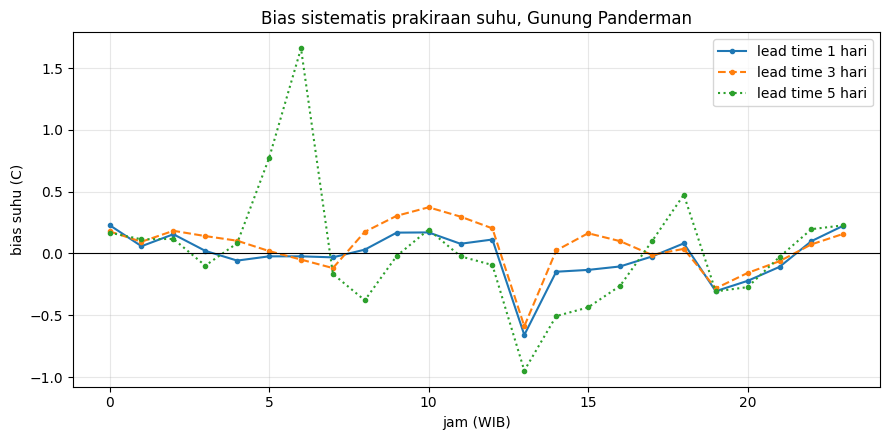

In [ ]:
import matplotlib.pyplot as plt

pr["hour"] = pr["time"].dt.hour
bias_per_jam = pr.groupby("hour")[[f"error_day{d}" for d in (1, 3, 5)]].mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
for d, style in zip((1, 3, 5), ("-", "--", ":")):
    ax.plot(bias_per_jam.index, bias_per_jam[f"error_day{d}"],
            style, marker="o", ms=3, label=f"lead time {d} hari")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("jam (WIB)")
ax.set_ylabel("bias suhu (C)")
ax.set_title("Bias sistematis prakiraan suhu, Gunung Panderman")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("bukti_bias_panderman.png", dpi=150)
plt.show()